# Homework 5 — Question 4 (Polynomial Regression + Ridge)

This notebook assumes the following CSV files are in the same folder as the notebook:

- `data_A.csv`
- `data_B_train.csv`
- `data_B_val.csv`

Each file should have columns `x` and `y`.

It produces:
1. A plot of polynomial fits on **data_A** for degrees **d = 1, 3, 9**
2. A plot of **train/val MSE vs degree** on **data_B**
3. A plot of **train/val MSE vs lambda** (ridge), fixing **d = 12**
4. Printed selections for **best degree** and **best lambda** based on validation MSE


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "."

PATH_A = f"{DATA_DIR}/data_A.csv"
PATH_B_TRAIN = f"{DATA_DIR}/data_B_train.csv"
PATH_B_VAL = f"{DATA_DIR}/data_B_val.csv"

def design_matrix(x, d):
    """Build polynomial design matrix [1, x, x^2, ..., x^d]."""
    x = np.asarray(x).reshape(-1, 1)
    return np.hstack([x**k for k in range(d + 1)])

def fit_ls(X, y):
    """Ordinary least squares via solve."""
    return np.linalg.solve(X.T @ X, X.T @ y)

def fit_ridge(X, y, lam):
    """Ridge regression solution: (X^T X + lam I)^-1 X^T y."""
    p = X.shape[1]
    return np.linalg.solve(X.T @ X + lam * np.eye(p), X.T @ y)

def mse(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    return np.mean((y_true - y_pred) ** 2)

print('Loaded helpers.')

Loaded helpers.


In [2]:
# Load data
A = pd.read_csv(PATH_A)
Btr = pd.read_csv(PATH_B_TRAIN)
Bva = pd.read_csv(PATH_B_VAL)

xA, yA = A["x"].to_numpy(), A["y"].to_numpy()
xtr, ytr = Btr["x"].to_numpy(), Btr["y"].to_numpy()
xva, yva = Bva["x"].to_numpy(), Bva["y"].to_numpy()

print("data_A:", A.shape, "| data_B_train:", Btr.shape, "| data_B_val:", Bva.shape)

data_A: (200, 2) | data_B_train: (20, 2) | data_B_val: (20, 2)


## Q4(A) Fit polynomials on data_A for degrees d = 1, 3, 9

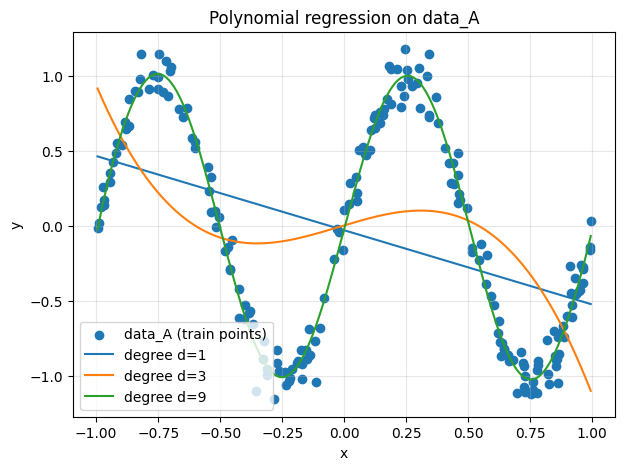

In [3]:
degrees_A = [1, 3, 9]
xs = np.linspace(xA.min(), xA.max(), 400)

plt.figure(figsize=(7,5))
plt.scatter(xA, yA, label="data_A (train points)")

for d in degrees_A:
    XA = design_matrix(xA, d)
    theta = fit_ls(XA, yA)
    ys = design_matrix(xs, d) @ theta
    plt.plot(xs, ys, label=f"degree d={d}")

plt.title("Polynomial regression on data_A")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Q4(B1) Train/Val MSE vs polynomial degree on data_B

Best degree by validation MSE: 9
Train MSE at best degree: 0.03905685177655562
Val   MSE at best degree: 0.07712854258160705


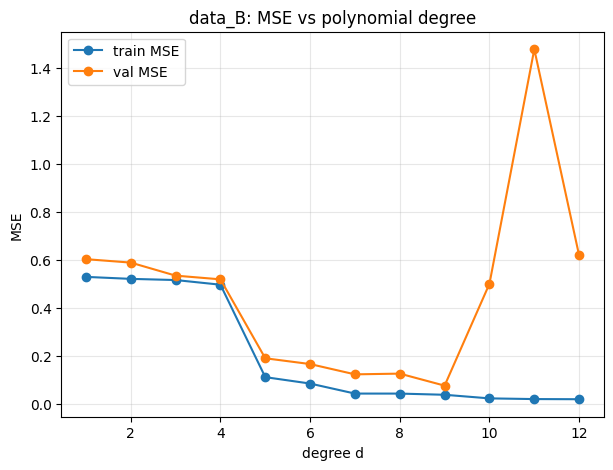

In [4]:
degrees = list(range(1, 13))
train_mse = []
val_mse = []

for d in degrees:
    Xtr = design_matrix(xtr, d)
    Xva = design_matrix(xva, d)
    theta = fit_ls(Xtr, ytr)
    train_mse.append(mse(ytr, Xtr @ theta))
    val_mse.append(mse(yva, Xva @ theta))

best_d = degrees[int(np.argmin(val_mse))]
print("Best degree by validation MSE:", best_d)
print("Train MSE at best degree:", train_mse[best_d-1])
print("Val   MSE at best degree:", val_mse[best_d-1])

plt.figure(figsize=(7,5))
plt.plot(degrees, train_mse, marker="o", label="train MSE")
plt.plot(degrees, val_mse, marker="o", label="val MSE")
plt.title("data_B: MSE vs polynomial degree")
plt.xlabel("degree d")
plt.ylabel("MSE")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Q4(B2) Ridge regression: Train/Val MSE vs \(\lambda\) for degree d = 12

We fix **d = 12** and sweep \(\lambda\) on a log scale.


Best lambda by validation MSE: 0.0016608827826277166
Train MSE at best lambda: 0.08034471774439385
Val   MSE at best lambda: 0.1445461933829057


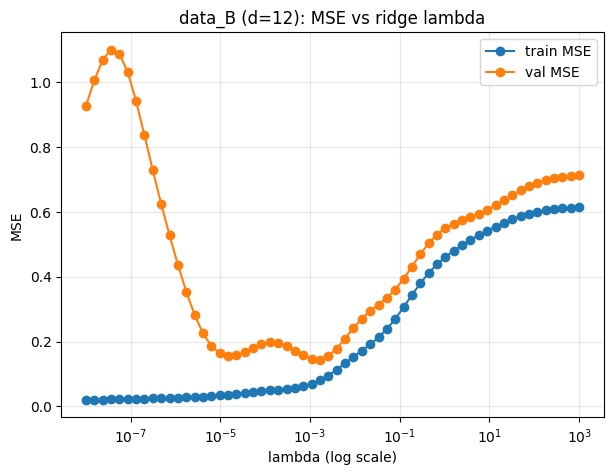

In [5]:
d = 12
Xtr = design_matrix(xtr, d)
Xva = design_matrix(xva, d)

lams = np.logspace(-8, 3, 60)
train_mse_l = []
val_mse_l = []

for lam in lams:
    theta = fit_ridge(Xtr, ytr, lam)
    train_mse_l.append(mse(ytr, Xtr @ theta))
    val_mse_l.append(mse(yva, Xva @ theta))

best_lam = lams[int(np.argmin(val_mse_l))]
print("Best lambda by validation MSE:", best_lam)
print("Train MSE at best lambda:", train_mse_l[int(np.argmin(val_mse_l))])
print("Val   MSE at best lambda:", val_mse_l[int(np.argmin(val_mse_l))])

plt.figure(figsize=(7,5))
plt.semilogx(lams, train_mse_l, marker="o", label="train MSE")
plt.semilogx(lams, val_mse_l, marker="o", label="val MSE")
plt.title("data_B (d=12): MSE vs ridge lambda")
plt.xlabel("lambda (log scale)")
plt.ylabel("MSE")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()